In [ ]:
import os
import re
import random
import string                   # for string operations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import plotly.express as px     # used for creating interactive visualizations easily.
import nltk   #Natural Language Toolkit
nltk.download('punkt', quiet=True) # pre-trained tokenization model that is used for sentence splitting and word tokenization

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("corona_tweets.csv")
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


In [ ]:
print(df['Sentiment'].value_counts())

Sentiment
Negative              1041
Positive               947
Neutral                619
Extremely Positive     599
Extremely Negative     592
Name: count, dtype: int64


In [ ]:
# Separating positive_tweets and negative_tweets and making them equal
positive_tweets = list(df[df['Sentiment'] == 'Positive']['OriginalTweet'])
negative_tweets = list(df[df['Sentiment'] == 'Negative']['OriginalTweet'])

In [ ]:
positive_tweets[6]

'#Coronavirus is "an exposure of all the holes in the social safety net," says NELP Government Affairs Director Judy Conti\r\r\n\r\r\n#UI #Unemployment #PaidLeaveForAll\r\r\nhttps://t.co/BrCY9IJWSv'

In [ ]:
negative_tweets[6]

"Fellow Uni instructors! COVID-19 f2f class cancelations are  inconvenient! But remember you're salaried employees. Maybe call/email HR or your union &amp; demand to know how hourly workers (clerical, food-service, custodial, etc) will be  compensated during campus closures?"

In [ ]:
len(positive_tweets), len(negative_tweets)

(947, 1041)

In [ ]:
# Splitting training and testing set
positive_train, positive_test = train_test_split(positive_tweets, test_size=0.2, random_state=42)
negative_train, negative_test = train_test_split(negative_tweets, test_size=0.2, random_state=42)

In [ ]:
print("Size of training dataset:", len(positive_train), ',', len(positive_test))
print("Size of testing dataset:", len(negative_train), ',', len(negative_test))

Size of training dataset: 757 , 190
Size of testing dataset: 832 , 209


In [ ]:
print('Positive Tweet:')
print(positive_tweets[random.randint(0,947)])

print('\nNegative Tweet:')
print(negative_tweets[random.randint(0,947)])

Positive Tweet:

https://t.co/aMczSMUuOs

Negative Tweet:

#Covid_19 #CoronaOutbreak #panicbuying https://t.co/kTPcYA9vtY


In [ ]:
positive_tweets[1:5]

['Voting in the age of #coronavirus = hand sanitizer ? #SuperTuesday https://t.co/z0BeL4O6Dk',
 'Best quality couches at unbelievably low prices available to order.\r\r\n\r\r\nWe are in Boksburg GP \r\r\n\r\r\nFor more info WhatsApp:\r\r\n084 764 8086\r\r\n\r\r\n#SuperTuesdsy #PowerTalk \r\r\n#Covid_19 #SayEntrepreneur \r\r\n#DJSBU https://t.co/HhDJhyQ2Dc',
 'While we were busy watching election returns and bracing for a Covid-19 outbreak, Trump nominated a chemical-industry lobbyist to head the Consumer Product Safety Commission https://t.co/M2ShHI1Tn0',
 "That's about a week from now. A bit optimistic.  Probably it will take another month.  Supply chain may be recovering, demand chain will be non-existent in US and Europe for the next month or two.\r\r\n$spx $qqq $es $nq https://t.co/yXcOfL0BnI"]

In [ ]:
tweet=positive_tweets[0]
tweet

"When I couldn't find hand sanitizer at Fred Meyer, I turned to #Amazon. But $114.97 for a 2 pack of Purell??!!Check out how  #coronavirus concerns are driving up prices. https://t.co/ygbipBflMY"

In [ ]:
tweet.split()

['When',
 'I',
 "couldn't",
 'find',
 'hand',
 'sanitizer',
 'at',
 'Fred',
 'Meyer,',
 'I',
 'turned',
 'to',
 '#Amazon.',
 'But',
 '$114.97',
 'for',
 'a',
 '2',
 'pack',
 'of',
 'Purell??!!Check',
 'out',
 'how',
 '#coronavirus',
 'concerns',
 'are',
 'driving',
 'up',
 'prices.',
 'https://t.co/ygbipBflMY']

In [ ]:
re.findall("[\w]+" , tweet)

['When',
 'I',
 'couldn',
 't',
 'find',
 'hand',
 'sanitizer',
 'at',
 'Fred',
 'Meyer',
 'I',
 'turned',
 'to',
 'Amazon',
 'But',
 '114',
 '97',
 'for',
 'a',
 '2',
 'pack',
 'of',
 'Purell',
 'Check',
 'out',
 'how',
 'coronavirus',
 'concerns',
 'are',
 'driving',
 'up',
 'prices',
 'https',
 't',
 'co',
 'ygbipBflMY']

In [ ]:
nltk.download('punkt') # pre-trained tokenization model that is used for sentence splitting and word tokenization


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
nltk.tokenize.word_tokenize(tweet , preserve_line=True)

['When',
 'I',
 'could',
 "n't",
 'find',
 'hand',
 'sanitizer',
 'at',
 'Fred',
 'Meyer',
 ',',
 'I',
 'turned',
 'to',
 '#',
 'Amazon.',
 'But',
 '$',
 '114.97',
 'for',
 'a',
 '2',
 'pack',
 'of',
 'Purell',
 '?',
 '?',
 '!',
 '!',
 'Check',
 'out',
 'how',
 '#',
 'coronavirus',
 'concerns',
 'are',
 'driving',
 'up',
 'prices.',
 'https',
 ':',
 '//t.co/ygbipBflMY']

In [ ]:
from nltk.tokenize import word_tokenize

In [ ]:
tweetTokens=word_tokenize(tweet , preserve_line=True)

In [ ]:
##re.sub("['!?.#]+ " ," " ,tweet)

In [ ]:
tweetTokens

['When',
 'I',
 'could',
 "n't",
 'find',
 'hand',
 'sanitizer',
 'at',
 'Fred',
 'Meyer',
 ',',
 'I',
 'turned',
 'to',
 '#',
 'Amazon.',
 'But',
 '$',
 '114.97',
 'for',
 'a',
 '2',
 'pack',
 'of',
 'Purell',
 '?',
 '?',
 '!',
 '!',
 'Check',
 'out',
 'how',
 '#',
 'coronavirus',
 'concerns',
 'are',
 'driving',
 'up',
 'prices.',
 'https',
 ':',
 '//t.co/ygbipBflMY']

In [ ]:
sent_tokenize?

Object `sent_tokenize` not found.


In [ ]:
tweet

"When I couldn't find hand sanitizer at Fred Meyer, I turned to #Amazon. But $114.97 for a 2 pack of Purell??!!Check out how  #coronavirus concerns are driving up prices. https://t.co/ygbipBflMY"

In [ ]:

from nltk.tokenize import sent_tokenize
nltk.download('punkt_tab')
sent_tokenize(tweet, language="english")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


["When I couldn't find hand sanitizer at Fred Meyer, I turned to #Amazon.",
 'But $114.97 for a 2 pack of Purell??!',
 '!Check out how  #coronavirus concerns are driving up prices.',
 'https://t.co/ygbipBflMY']

In [ ]:
sent_tokenize(tweet, language="english")

["When I couldn't find hand sanitizer at Fred Meyer, I turned to #Amazon.",
 'But $114.97 for a 2 pack of Purell??!',
 '!Check out how  #coronavirus concerns are driving up prices.',
 'https://t.co/ygbipBflMY']

#### Lemmatization
<ul>
    <li>Lemmatization reduces the words properly such that the reduced word also belongs to the language.</li>
    <li>The output of lemmatization is the root lemma and not the root stem (as in stemming).</li>
    <li>Example:  'runs', 'running', 'ran' are all formed from the same word 'run' hence their lemma is 'run'. </li>
</ul>

#### Stemming
<ul>
    <li>Stemming does not generate actual words where as lemmatization does generate actual words.</li>
    <li>Stemming is a rule based technique and is applied step by step on words without any additional context, it is much faster as compared to lemmatization which needs the entire text or POS tag to generate the root lemma correctly.</li>
    <li>If you need speed then stemming can be preffered else lemmatization is better in most cases.</li>
</ul>

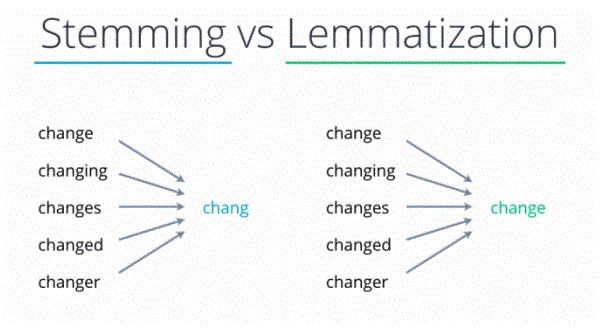

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# removing hyperlinks and hashtags

tweet2=re.sub("https?://[^\s\n]+" , " " , tweet)
tweet2=re.sub("#" , "" , tweet2)
tweet2

"When I couldn't find hand sanitizer at Fred Meyer, I turned to Amazon. But $114.97 for a 2 pack of Purell??!!Check out how  coronavirus concerns are driving up prices.  "

In [ ]:
Tokenizer=TweetTokenizer(strip_handles=True , preserve_case=False , reduce_len=True)
tweetTokens=Tokenizer.tokenize(tweet2)

In [ ]:
#stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
len(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


198

In [ ]:
stopwords_eng=stopwords.words('english')

In [ ]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
clean_tweet=[]
for  word in tweetTokens:
  if (word not in stopwords_eng and  word not in string.punctuation):
    clean_tweet.append(word)
clean_tweet

['find',
 'hand',
 'sanitizer',
 'fred',
 'meyer',
 'turned',
 'amazon',
 '114.97',
 '2',
 'pack',
 'purell',
 'check',
 'coronavirus',
 'concerns',
 'driving',
 'prices']

In [ ]:
stemmer=PorterStemmer()
tweet_stem=[]
for  word in clean_tweet:
  stemWord=stemmer.stem(word)
  tweet_stem.append(stemWord)

tweet_stem

['find',
 'hand',
 'sanit',
 'fred',
 'meyer',
 'turn',
 'amazon',
 '114.97',
 '2',
 'pack',
 'purel',
 'check',
 'coronaviru',
 'concern',
 'drive',
 'price']

In [ ]:
lemmitizer=WordNetLemmatizer()
tweet_lem=[]
for  word in clean_tweet:
  stemWord=lemmitizer.lemmatize(word)
  tweet_lem.append(stemWord)


tweet_lem

['find',
 'hand',
 'sanitizer',
 'fred',
 'meyer',
 'turned',
 'amazon',
 '114.97',
 '2',
 'pack',
 'purell',
 'check',
 'coronavirus',
 'concern',
 'driving',
 'price']

In [ ]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:

def TweetProcessor(tweet):
  stopwords_eng= stopwords.words('english')
  Lemmitizer= WordNetLemmatizer()
  tweet2=re.sub("https?://[^\s\n]+" , " " , tweet)
  tweet2=re.sub("#" , "" , tweet2)
  tweet2= re.sub("\d"," ",tweet2 )
  Tokenizer=TweetTokenizer(strip_handles=True , preserve_case=False , reduce_len=True)
  tweetTokens=Tokenizer.tokenize(tweet2)
  clean_tweet=[]
  for  word in tweetTokens:
    if (word not in stopwords_eng and  word not in string.punctuation):
      lemWord=lemmitizer.lemmatize(word)
      clean_tweet.append(lemWord)
  return clean_tweet



In [ ]:
positive_tweets[2]

'Best quality couches at unbelievably low prices available to order.\r\r\n\r\r\nWe are in Boksburg GP \r\r\n\r\r\nFor more info WhatsApp:\r\r\n084 764 8086\r\r\n\r\r\n#SuperTuesdsy #PowerTalk \r\r\n#Covid_19 #SayEntrepreneur \r\r\n#DJSBU https://t.co/HhDJhyQ2Dc'

In [ ]:
TweetProcessor(positive_tweets[2])

['best',
 'quality',
 'couch',
 'unbelievably',
 'low',
 'price',
 'available',
 'order',
 'boksburg',
 'gp',
 'info',
 'whatsapp',
 'supertuesdsy',
 'powertalk',
 'covid',
 'sayentrepreneur',
 'djsbu']